In [1]:
import kagglehub
import pandas as pd
import numpy as np

df = pd.read_csv('/home/nikita/TS.csv')

In [2]:
df['month'] = df['Time'].str[:1].astype(int)
df['day'] = df['Time'].str.split('/').str[1].str.split('/').str[0].astype(int)
df['hour'] = df['Time'].str.extract(' (.*):').astype(int)
df['hour'] = df['Time'].str.extract(' (.*):').astype(int)
df['lag_1'] = df['Users'].shift(1).fillna(0)
df['lag_2'] = df['lag_1'].shift(1).fillna(0)
df['lag_3'] = df['lag_2'].shift(1).fillna(0)
df['mean_2'] = (df['lag_1'] + df['lag_2'] + df['lag_3'] ) / 3
df['Users'] = df['Users'] / 1000
df['lag_1'] = df['lag_1'] / 1000
df['lag_2'] = df['lag_2'] / 1000
df['lag_3'] = df['lag_3'] / 1000
df['mean_2'] = df['mean_2'] / 1000
df

,Time,Users,month,day,hour,lag_1,lag_2,lag_3,mean_2
0,1/1/17 0:00,34.002,1,1,0,0.000,0.000,0.000,0.000000
1,1/1/17 1:00,37.947,1,1,1,34.002,0.000,0.000,11.334000
2,1/1/17 2:00,41.517,1,1,2,37.947,34.002,0.000,23.983000
3,1/1/17 3:00,44.476,1,1,3,41.517,37.947,34.002,37.822000
4,1/1/17 4:00,46.234,1,1,4,44.476,41.517,37.947,41.313333
...,...,...,...,...,...,...,...,...,...
2620,4/20/17 5:00,34.833,4,20,5,33.220,29.115,25.430,29.255000
2621,4/20/17 6:00,35.932,4,20,6,34.833,33.220,29.115,32.389333
2622,4/20/17 7:00,38.418,4,20,7,35.932,34.833,33.220,34.661667
2623,4/20/17 8:00,40.238,4,20,8,38.418,35.932,34.833,36.394333


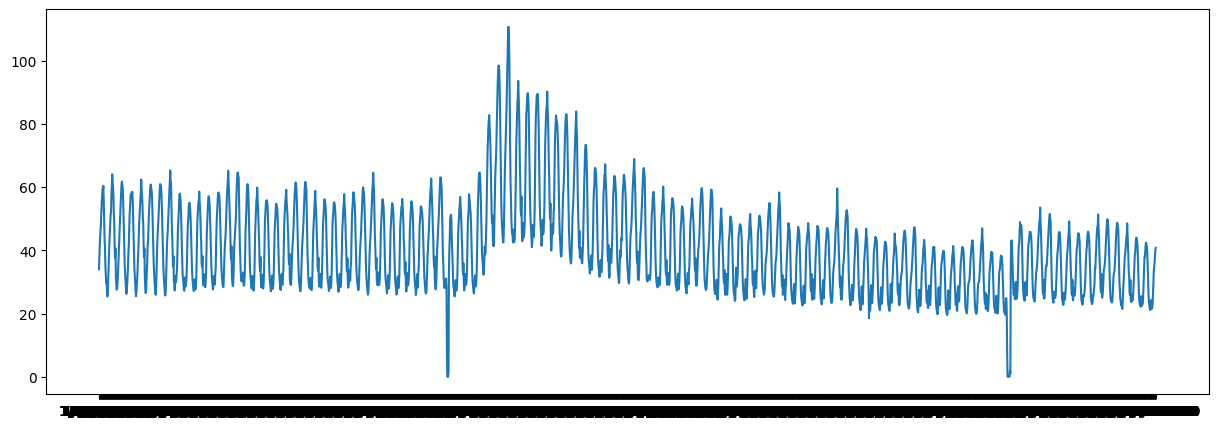

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(df['Time'], df['Users'])
plt.show()

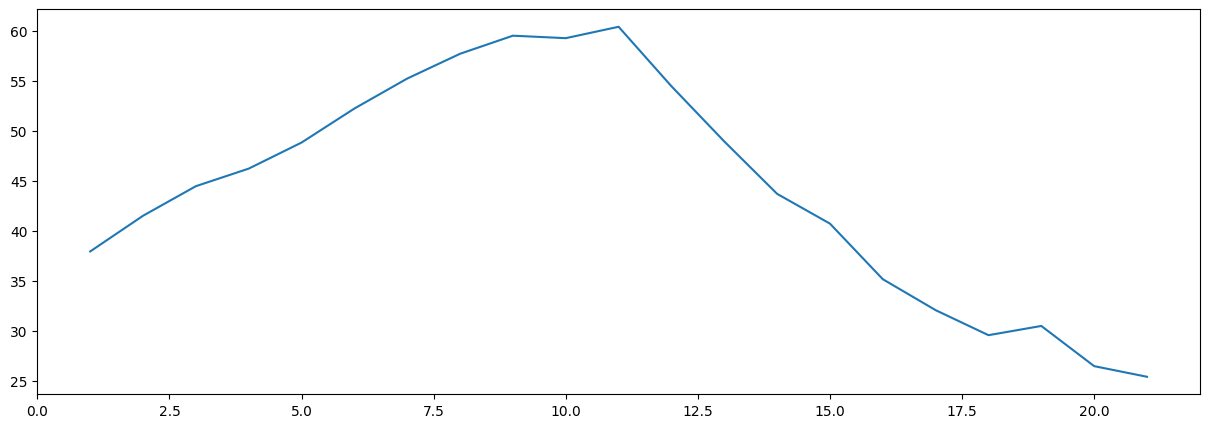

In [4]:
plt.figure(figsize=(15,5))
plt.plot(df['hour'][1:22], df['Users'][1:22])
plt.show()

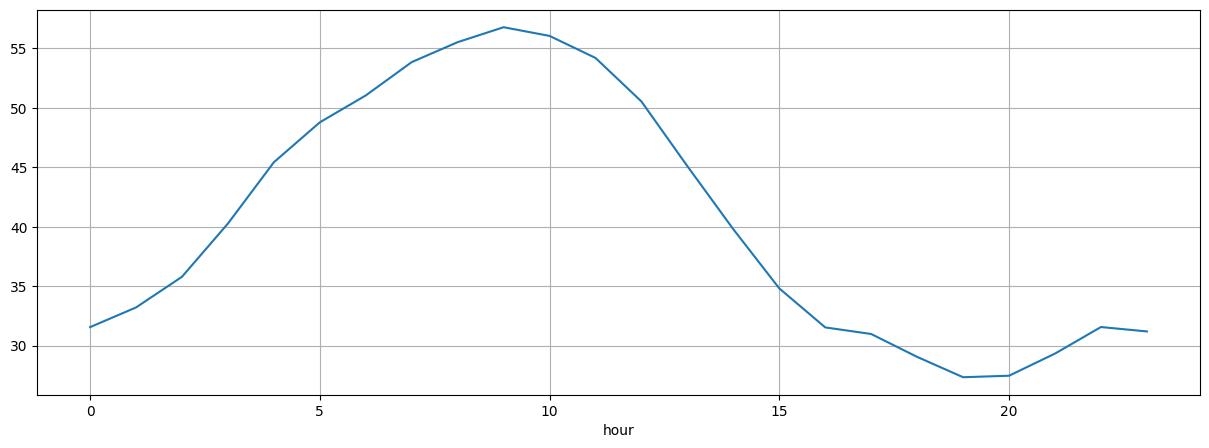

In [5]:
hourly_avg = df.groupby('hour')['Users'].mean()
plt.figure(figsize=(15,5))
hourly_avg.plot(kind='line')
plt.grid(True)
plt.show()

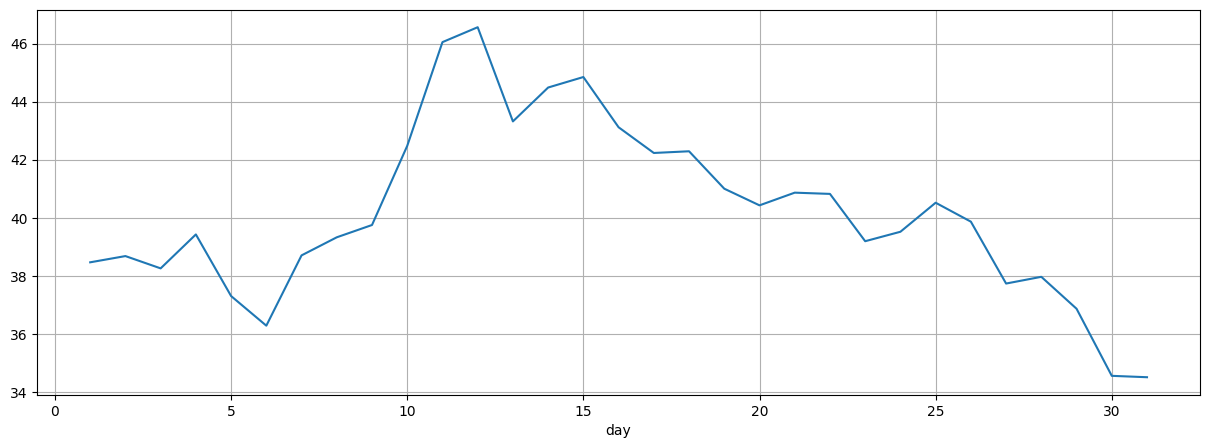

In [6]:
daily_avg = df.groupby('day')['Users'].mean()
plt.figure(figsize=(15,5))
daily_avg.plot(kind='line')
plt.grid(True)
plt.show()

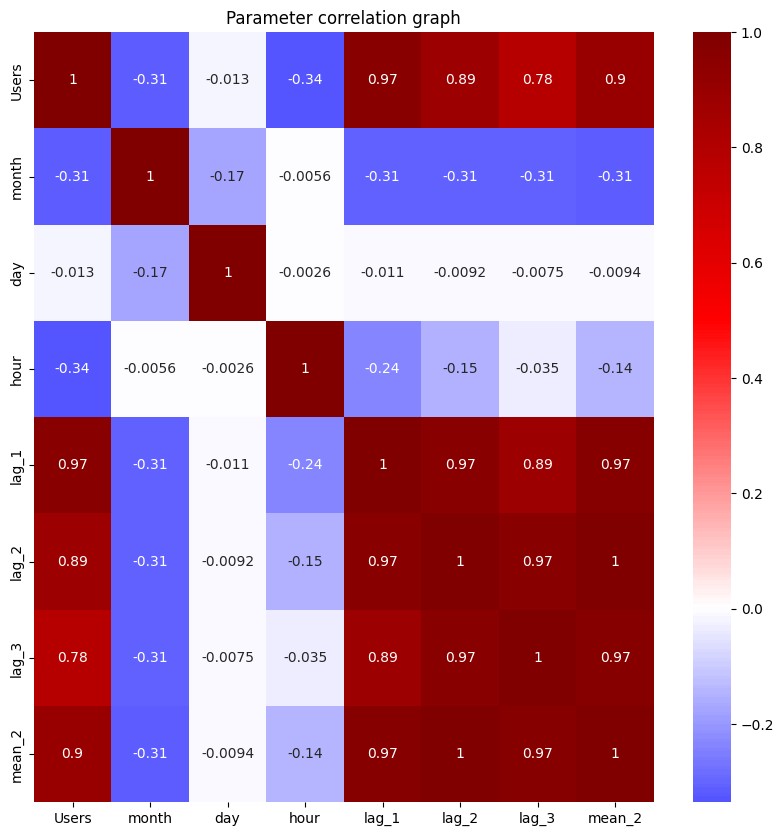

In [7]:
import seaborn as seaborn

df = df.drop(['Time'], axis = 1)

plt.figure(figsize=(10, 10))
seaborn.heatmap(df.corr(), annot=True, cmap='seismic', center=0)
plt.title('Parameter correlation graph')
plt.show()

In [8]:
df_train = df[(df['month'].isin([1, 2, 3])) & (df['day'] % 5 != 0)].reset_index(drop=True)
df_train

,Users,month,day,hour,lag_1,lag_2,lag_3,mean_2
0,34.002,1,1,0,0.000,0.000,0.000,0.000000
1,37.947,1,1,1,34.002,0.000,0.000,11.334000
2,41.517,1,1,2,37.947,34.002,0.000,23.983000
3,44.476,1,1,3,41.517,37.947,34.002,37.822000
4,46.234,1,1,4,44.476,41.517,37.947,41.313333
...,...,...,...,...,...,...,...,...
1746,20.321,3,31,19,21.181,21.411,22.921,21.837667
1747,20.086,3,31,20,20.321,21.181,21.411,20.971000
1748,21.742,3,31,21,20.086,20.321,21.181,20.529333
1749,24.805,3,31,22,21.742,20.086,20.321,20.716333


In [9]:
df_test = df[(df['month'].isin([4]))].reset_index(drop=True)
df_test

,Users,month,day,hour,lag_1,lag_2,lag_3,mean_2
0,29.683,4,1,0,28.075,24.805,21.742,24.874000
1,29.870,4,1,1,29.683,28.075,24.805,27.521000
2,30.332,4,1,2,29.870,29.683,28.075,29.209333
3,31.550,4,1,3,30.332,29.870,29.683,29.961667
4,34.221,4,1,4,31.550,30.332,29.870,30.584000
...,...,...,...,...,...,...,...,...
461,34.833,4,20,5,33.220,29.115,25.430,29.255000
462,35.932,4,20,6,34.833,33.220,29.115,32.389333
463,38.418,4,20,7,35.932,34.833,33.220,34.661667
464,40.238,4,20,8,38.418,35.932,34.833,36.394333


In [10]:
df_val = df[(df['month'].isin([1, 2, 3])) & (df['day'] % 5 == 0)].reset_index(drop=True)
df_val

,Users,month,day,hour,lag_1,lag_2,lag_3,mean_2
0,33.821,1,5,0,30.899,29.205,26.457,28.853667
1,37.426,1,5,1,33.821,30.899,29.205,31.308333
2,40.515,1,5,2,37.426,33.821,30.899,34.048667
3,44.825,1,5,3,40.515,37.426,33.821,37.254000
4,48.796,1,5,4,44.825,40.515,37.426,40.922000
...,...,...,...,...,...,...,...,...
403,21.021,3,30,19,26.240,22.709,22.934,23.961000
404,20.865,3,30,20,21.021,26.240,22.709,23.323333
405,26.071,3,30,21,20.865,21.021,26.240,22.708667
406,28.596,3,30,22,26.071,20.865,21.021,22.652333


In [11]:
x_train = df_train.drop(['Users'], axis = 1).to_numpy().astype('float32')
y_train = df_train['Users'].to_numpy().astype('float32')
x_test = df_test.drop(['Users'], axis = 1).to_numpy().astype('float32')
y_test = df_test['Users'].to_numpy().astype('float32')
x_val= df_val.drop(['Users'], axis = 1).to_numpy().astype('float32')
y_val = df_val['Users'].to_numpy().astype('float32')

In [72]:
import tensorflow as tf
import keras
from tensorflow.keras.callbacks import EarlyStopping

model = keras.Sequential([
    keras.layers.Dense(256, input_shape=(x_train.shape[1],)),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(128, activation ='relu',),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation ='relu', kernel_regularizer='l1'),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(128),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64),
    keras.layers.Dense(32, activation ='relu'),
    keras.layers.Dense(1)
])


model.compile(  optimizer = keras.optimizers.Adam(learning_rate = 1e-3),
                loss = 'mse',
                metrics = ['R2Score']
                )

early_stopping = EarlyStopping(
                    monitor='r2_score',
                    patience = 50,
                    min_delta = 0.001,
                    verbose = 0,
                    restore_best_weights = True,
                    mode = 'max'
                    )

model.fit(
        x = x_train,
        y = y_train,
        batch_size = 64,
        epochs = 2000,
        verbose = 0,
        callbacks = [early_stopping], 
        shuffle = False,
        validation_data = (x_val, y_val),
        validation_batch_size = 32
        )

train_loss, keras_train_r2 = model.evaluate(x_train, y_train)
test_loss, keras_test_r2 = model.evaluate(x_test, y_test)
print('\nдля нейронной сети R^2 метрика для обучающей \ тестовой выборки:', keras_train_r2, ' \ ', keras_test_r2)

15/15 [==============================] - 0s 1ms/step - loss: 26.9566 - r2_score: 0.7384

для нейронной сети R^2 метрика для обучающей \ тестовой выборки: 0.8041136860847473  \  0.7383869886398315


In [96]:
last_elem = df.loc(0)[df.shape[0]-1]

month = last_elem['month']
day = last_elem['day']
hour = last_elem['hour']
lag_1 = last_elem['lag_1']
lag_2 = last_elem['lag_2']
lag_3 = last_elem['lag_3']
mean_2 = last_elem['mean_2']     

history = []

for _ in range(30 * 24): #прогноз на 30 дней по 24 часа
    input_array = np.array([[month, day, hour, lag_1, lag_2, lag_3, mean_2]], dtype=np.float32)
    pred = (model.predict(input_array, verbose=0))[0][0]
    history.append(pred)
    lag_1, lag_2, lag_3 = pred, lag_1, lag_2
    mean_2 = (lag_1 + lag_2 + lag_3) / 3
    if hour + 1 >= 24:
        hour = 0
        if day + 1 > 30:
            day = 1
            month += 1
        else:
            day += 1
    else:
        hour += 1
    # print(month, day, hour, pred)

In [97]:
fact = df['Users'].to_numpy().tolist()
predict = history

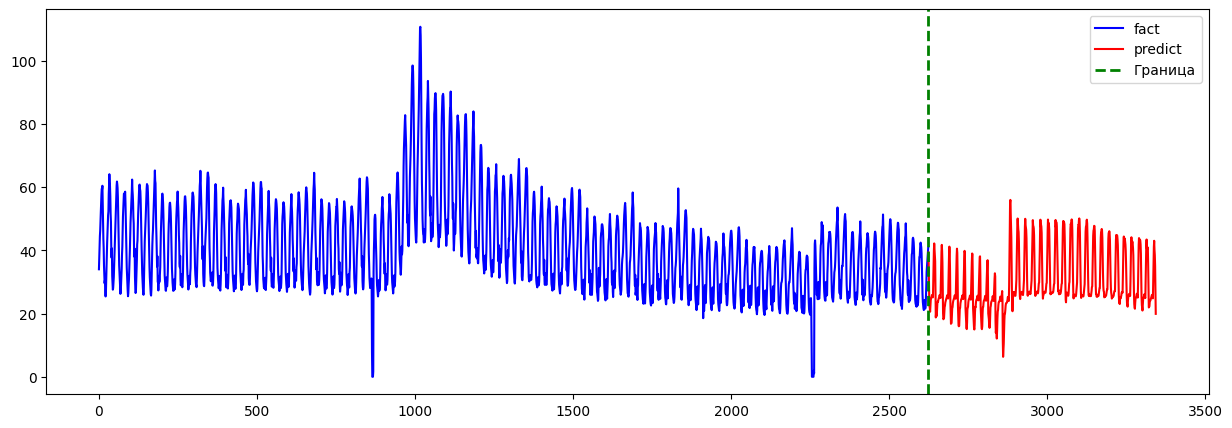

In [98]:
plt.figure(figsize=(15, 5))
plt.plot(range(len(fact)), fact, color='blue', label='fact')
plt.plot(range(len(fact), len(fact) + len(predict)), predict, color='red', label='predict')
plt.axvline(x=len(fact) - 1, color='green', linestyle='--', linewidth=2, label='Граница')
plt.legend()
plt.show()

In [108]:
import statsmodels.api as sm
from scipy import stats
from scipy.special import inv_boxcox

import matplotlib
%matplotlib inline
matplotlib.rcParams['figure.figsize'] = [17, 6]
matplotlib.rcParams['font.size'] = 12

Критерий Дики-Фуллера: p-value=0.1902


[]

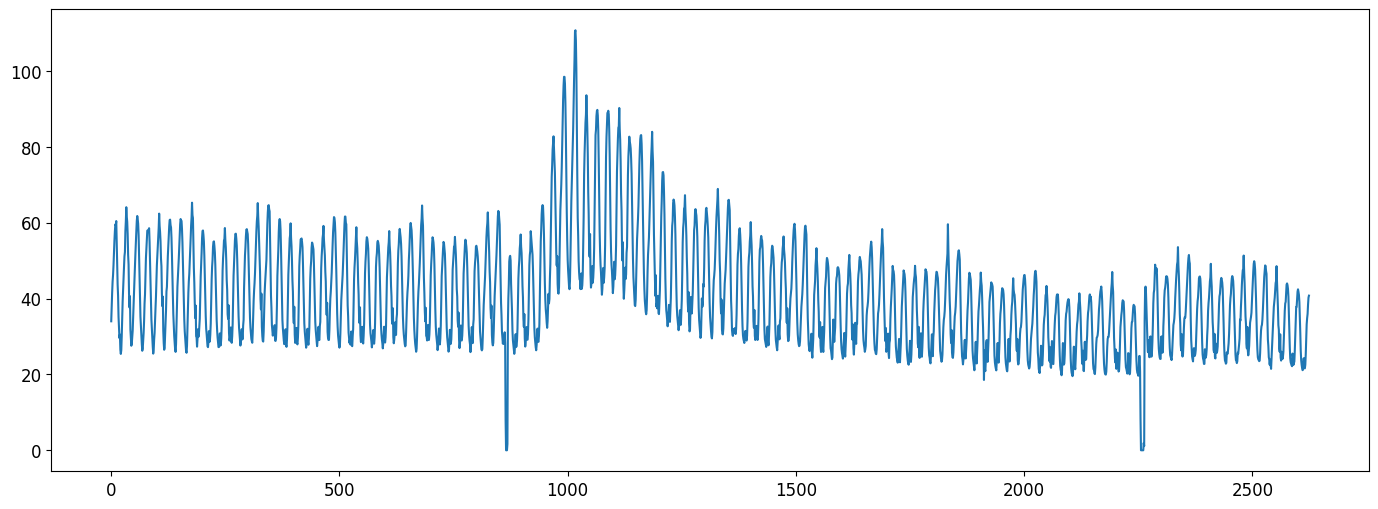

In [112]:
p = sm.tsa.stattools.adfuller(df.Users)[1]
print(f'Критерий Дики-Фуллера: p-value={p:.4f}')

df.Users.plot()
plt.plot()

Критерий Дики-Фуллера: p-value=0.0814


[]

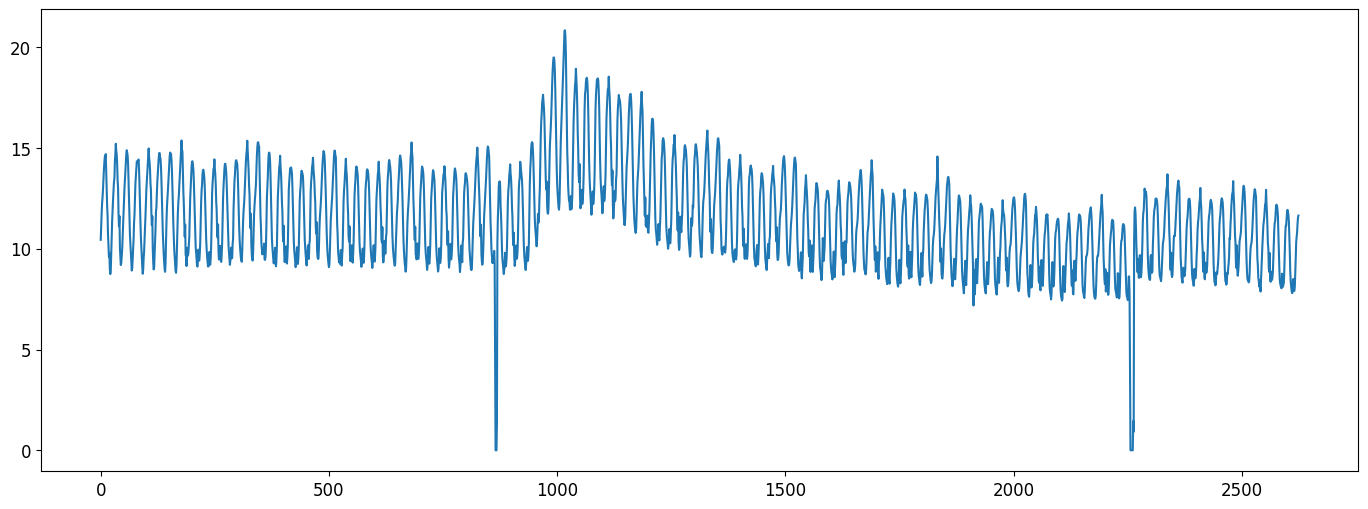

In [113]:
#избавлние от дисперсии

df['boxcox'], lmbda = stats.boxcox(df.Users+1)

p = sm.tsa.stattools.adfuller(df.boxcox)[1]
print(f'Критерий Дики-Фуллера: p-value={p:.4f}')

df.boxcox.plot()
plt.plot()

Критерий Дики-Фуллера: p-value=0.0000


[]

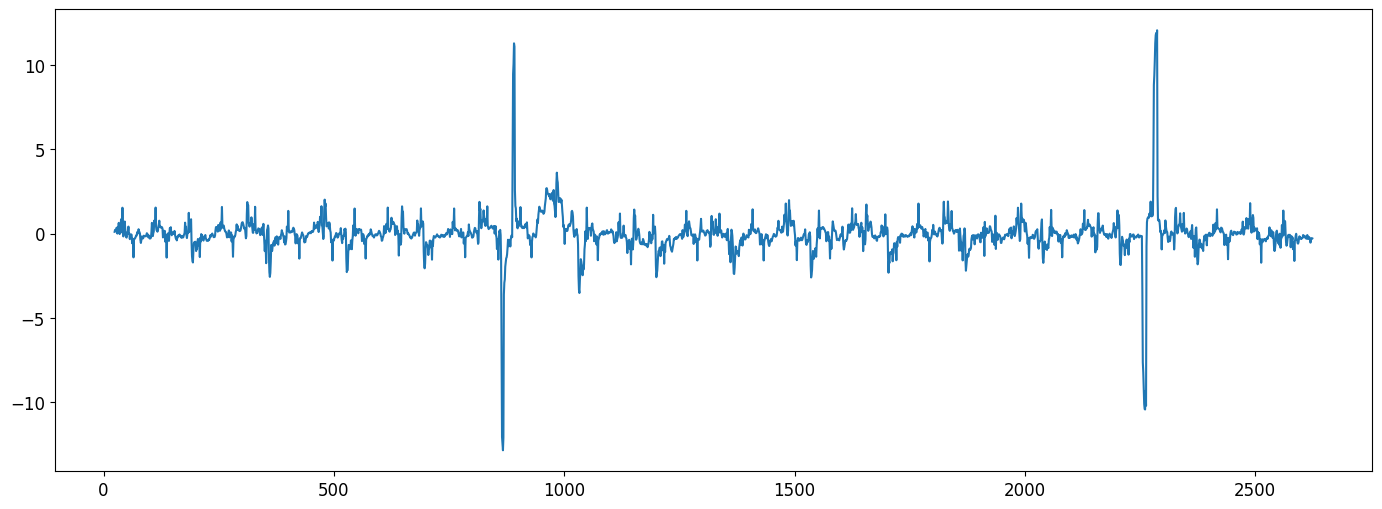

In [114]:
#избавлние от сезонности (24 часа)

df['boxcox_shifted_S'] = df.boxcox - df.boxcox.shift(24)

p = sm.tsa.stattools.adfuller(df.boxcox_shifted_S[24:])[1]
print(f'Критерий Дики-Фуллера: p-value={p:.4f}')

df.boxcox_shifted_S[24:].plot()
plt.plot()

In [115]:
#p-value < 0.05 поэтому данный ряд можно считать стационарным

In [124]:
#дифференцирование (на будущее)

# df['boxcox_shifted'] = df.boxcox_shifted_S - df.boxcox_shifted_S.shift(1)

# p = sm.tsa.stattools.adfuller(df.boxcox_shifted[25:])[1]
# print(f'Критерий Дики-Фуллера: p-value={p:.4f}')

# df.boxcox_shifted[25:].plot()
# plt.plot()

In [126]:
# инфу я брал отсюда https://medium.com/@yoskutik/%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7-%D0%B2%D1%80%D0%B5%D0%BC%D0%B5%D0%BD%D0%BD%D1%8B%D1%85-%D1%80%D1%8F%D0%B4%D0%BE%D0%B2-%D1%87%D0%B0%D1%81%D1%82%D1%8C-1-%D1%81%D1%82%D0%B0%D1%86%D0%B8%D0%BE%D0%BD%D0%B0%D1%80%D0%BD%D0%BE%D1%81%D1%82%D1%8C-74f45144ee86
# https://github.com/Yoskutik/Medium-Time-Series/blob/master/%D0%A7%D0%B0%D1%81%D1%82%D1%8C%201.%20%D0%A1%D1%82%D0%B0%D1%86%D0%B8%D0%BE%D0%BD%D0%B0%D1%80%D0%BD%D0%BE%D1%81%D1%82%D1%8C.ipynb